In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import os

data_dir = '/content/drive/MyDrive/bob-ros-images'

dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    label_mode=None,
    image_size=(64, 64),
    batch_size=32
)

dataset = dataset.map(lambda x: tf.image.random_flip_left_right((x - 127.5) / 127.5))
dataset = dataset.shuffle(406).cache().prefetch(tf.data.AUTOTUNE)


Found 406 files.


In [3]:
def make_generator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(100,)),
        tf.keras.layers.Dense(4 * 4 * 512, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Reshape((4, 4, 512)),

        tf.keras.layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False),  # (8, 8, 256)
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),  # (16, 16, 128)
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),  # (32, 32, 64)
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')  # (64, 64, 3)
    ])
    return model

def make_discriminator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])
    return model

# Loss functions
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output)*0.9, real_output)  # Label smoothing
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = make_generator_model()
discriminator = make_discriminator_model()

generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.5)

# Training setup

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

os.makedirs('./generated_images', exist_ok=True)
g_losses, d_losses = [], []

def add_noise(images, stddev=0.05):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=stddev)
    return images + noise

noise_dim = 100
@tf.function
def train_step(images):
    noise = tf.random.normal([32, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_images_noisy=add_noise(images)
        generated_images_noisy=add_noise(generated_images)

        real_output = discriminator(real_images_noisy, training=True)
        fake_output = discriminator(generated_images_noisy, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(((predictions[i] + 1) * 127.5).numpy().astype(np.uint8))
        plt.axis('off')

    plt.savefig(f'generated_images/image_at_epoch_{epoch:04d}.png')
    plt.show()



In [6]:
# Training loop
num_examples_to_generate = 16

tf.random.set_seed(42)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

def train(dataset, epochs,start_epoch=0):
    for epoch in range(start_epoch, start_epoch + epochs):
        print(f"Starting epoch {epoch+1}")
        for image_batch in dataset:
          gen_loss, disc_loss = train_step(image_batch)

        g_losses.append(gen_loss.numpy())
        d_losses.append(disc_loss.numpy())

        if (epoch + 1) % 100 == 0:
            generate_and_save_images(generator, epoch + 1, seed)
            print(f"Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}")

        if (epoch + 1) % 100 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        if (epoch + 1) % 1000 == 0:
           generator.save(f'/content/drive/MyDrive/bob_ross_gan/generator_epoch_{epoch+1}.keras')
           discriminator.save(f'/content/drive/MyDrive/bob_ross_gan/discriminator_epoch_{epoch+1}.keras')

    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training Losses')
    plt.savefig('loss_curve.png')
    plt.show()



In [ ]:
import re

latest = tf.train.latest_checkpoint(checkpoint_dir)
checkpoint.restore(latest)

start_epoch = int(re.findall(r'ckpt-(\d+)', latest)[0])*100
train(dataset,epochs=2000,start_epoch=start_epoch)

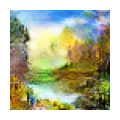

In [359]:
from tensorflow.keras.models import load_model

generator = load_model('/content/drive/MyDrive/bob_ross_gan/generator_epoch_12000.keras')

def generate_images(generator, noise_dim=100, num_images=1):
    seed = tf.random.normal([num_images, noise_dim])
    predictions = generator(seed, training=False)

    fig = plt.figure(figsize=(1, 1))
    for i in range(num_images):
        plt.subplot(1, 1, i+1)
        img = (predictions[i] * 127.5 + 127.5).numpy().astype(np.uint8)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

generate_images(generator)
